In [2]:
import os
#import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchsummary import summary
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
data_dir = "/kaggle/input/flowers/"
train_dir = os.path.join(data_dir, "Training Data/Training Data") 
valid_dir = os.path.join(data_dir, "Validation Data/Validation Data")
test_dir = os.path.join(data_dir, "Testing Data/Testing Data")

In [25]:
#transformation (ONLY use data augmentation only on training to avoid overfitting)
Image_size = (224, 224) #most pretrained CNNs were trained on ImageNet where all images were resized to 224x224

train_transforms = transforms.Compose([
    transforms.Resize(Image_size),                          #to resize all images to be the same
    transforms.RandomHorizontalFlip(),                      #for diversity
    transforms.RandomRotation(20),                          #for diversity
    transforms.ToTensor(),                                  #convert to Tensor
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])])           #match ImageNet stats

valid_transforms = transforms.Compose([
    transforms.Resize(Image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])])

test_transforms = transforms.Compose([
    transforms.Resize(Image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [26]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
device

device(type='cuda')

In [8]:
#compared various pretrained models (DenseNet, MobileNetV2, EfficientNet-B0, ResNet-10) and chose 
#EfficientNet-B0: 237-layers, laptop friendly, middle ground of DenseNet and MobileNetv2. Better accuracy then MobileNetV2
#avoid overfitting, works great with small dataset, and fast training.

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False       #freeze all parameters


model.classifier = nn.Sequential( 
    nn.Linear(1280, 64),
    nn.ReLU(), 
    nn.Dropout(0.2), 
    
    nn.Linear(64, 10)
)

model = model.to(device)

In [9]:
from torchsummary import summary 

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

In [30]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, device, epochs=10, verbose=True):
    train_loss, valid_loss, valid_accuracy = [], [], []

    for epoch in range(epochs):
        model.train()
        train_batch_loss = 0
        valid_batch_loss = 0
        valid_batch_acc = 0
        
        # Training loop
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_batch_loss += loss.item()
        train_loss.append(train_batch_loss / len(train_loader))
        
        # Validation Loop
        model.eval()
        with torch.no_grad():
            for X, y in valid_loader:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                _, y_hat_labels = torch.softmax(y_hat, dim=1).topk(1, dim=1)
                loss = criterion(y_hat, y)
                valid_batch_loss += loss.item()
                valid_batch_acc += (y_hat_labels.squeeze() == y).type(torch.float32).mean().item()
                
        valid_loss.append(valid_batch_loss / len(valid_loader))
        valid_accuracy.append(valid_batch_acc / len(valid_loader))
                
        if verbose:
            print(f"Epoch {epoch + 1}:",
                  f"Train Loss: {train_loss[-1]:.3f}.",
                  f"Valid Loss: {valid_loss[-1]:.3f}.",
                  f"Valid Accuracy: {valid_accuracy[-1]:.2f}.")

    
    results = {"train_loss": train_loss,
               "valid_loss": valid_loss,
               "valid_accuracy": valid_accuracy}
    return results

In [11]:
criterion = nn.CrossEntropyLoss()     #multiclass Loss function
optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr = 0.001)

In [12]:
results = train_model(model, criterion, optimizer, train_loader, valid_loader, device, epochs=10)

Epoch 1: Train Loss: 1.053. Valid Loss: 0.731. Valid Accuracy: 0.78.
Epoch 2: Train Loss: 0.778. Valid Loss: 0.629. Valid Accuracy: 0.81.
Epoch 3: Train Loss: 0.700. Valid Loss: 0.608. Valid Accuracy: 0.81.
Epoch 4: Train Loss: 0.672. Valid Loss: 0.595. Valid Accuracy: 0.81.
Epoch 5: Train Loss: 0.640. Valid Loss: 0.602. Valid Accuracy: 0.81.
Epoch 6: Train Loss: 0.624. Valid Loss: 0.579. Valid Accuracy: 0.82.
Epoch 7: Train Loss: 0.606. Valid Loss: 0.587. Valid Accuracy: 0.81.
Epoch 8: Train Loss: 0.590. Valid Loss: 0.588. Valid Accuracy: 0.81.
Epoch 9: Train Loss: 0.593. Valid Loss: 0.576. Valid Accuracy: 0.82.
Epoch 10: Train Loss: 0.566. Valid Loss: 0.574. Valid Accuracy: 0.82.


The validation score is 0.80+, both validation loss and training loss have a decreasing trend. Overall, the model generalizing well and the scores are stable. This results is from replacing the classifier of EfficientNet model. There might be room to improve if unfreezing some layers and retrain.

In [13]:
model2 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
for name, param in model2.named_parameters():
    if "features.6" in name:   # last block
        param.requires_grad = True

model2.classifier = nn.Sequential( 
    nn.Linear(1280, 64),
    nn.ReLU(), 
    nn.Dropout(0.2), 
    
    nn.Linear(64, 10)
)

model2 = model2.to(device)
criterion = nn.CrossEntropyLoss()     #multiclass Loss function
optimizer = torch.optim.Adam([
        {"params": model2.classifier.parameters(), "lr": 1e-4}, 
        {"params": model2.features[6].parameters(), "lr": 1e-4} 
    ])

In [14]:
#attempt 2
results = train_model(model2, criterion, optimizer, train_loader, valid_loader, device, epochs=10)

Epoch 1: Train Loss: 1.274. Valid Loss: 0.510. Valid Accuracy: 0.86.
Epoch 2: Train Loss: 0.561. Valid Loss: 0.375. Valid Accuracy: 0.89.
Epoch 3: Train Loss: 0.450. Valid Loss: 0.346. Valid Accuracy: 0.90.
Epoch 4: Train Loss: 0.391. Valid Loss: 0.313. Valid Accuracy: 0.91.
Epoch 5: Train Loss: 0.327. Valid Loss: 0.297. Valid Accuracy: 0.91.
Epoch 6: Train Loss: 0.290. Valid Loss: 0.297. Valid Accuracy: 0.92.
Epoch 7: Train Loss: 0.266. Valid Loss: 0.299. Valid Accuracy: 0.92.
Epoch 8: Train Loss: 0.234. Valid Loss: 0.325. Valid Accuracy: 0.91.
Epoch 9: Train Loss: 0.205. Valid Loss: 0.322. Valid Accuracy: 0.91.
Epoch 10: Train Loss: 0.188. Valid Loss: 0.320. Valid Accuracy: 0.91.


The second attempt of training my model after unfreezing the last layer of EfficientNet-B0 model seems to hover around 0.91 validation accuracy. There is a sign of overfitting as the training loss decrease but validation loss starts to increase from epoch 8. This model might be overfittinh. Unfreeze another layer to see if it helps.

In [34]:
model3 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
for name, param in model3.named_parameters():
    if "features.5" in name or "features.6" in name:
        param.requires_grad = True

model3.classifier = nn.Sequential( 
    nn.Linear(1280, 64),
    nn.ReLU(), 
    nn.Dropout(0.2), 
    
    nn.Linear(64, 10)
)

model3 = model3.to(device)
criterion = nn.CrossEntropyLoss()     #multiclass Loss function
optimizer = torch.optim.Adam([
        {"params": model3.classifier.parameters(), "lr": 1e-4}, 
        {"params": model3.features[6].parameters(), "lr": 1e-5},
        {"params": model3.features[5].parameters(), "lr": 2e-5} #make smaller adjustment
    ])

In [35]:
# attempt 3
results = train_model(model3, criterion, optimizer, train_loader, valid_loader, device, epochs=10)

Epoch 1: Train Loss: 1.589. Valid Loss: 0.935. Valid Accuracy: 0.78.
Epoch 2: Train Loss: 0.813. Valid Loss: 0.594. Valid Accuracy: 0.83.
Epoch 3: Train Loss: 0.657. Valid Loss: 0.484. Valid Accuracy: 0.86.
Epoch 4: Train Loss: 0.570. Valid Loss: 0.442. Valid Accuracy: 0.87.
Epoch 5: Train Loss: 0.516. Valid Loss: 0.412. Valid Accuracy: 0.88.
Epoch 6: Train Loss: 0.478. Valid Loss: 0.378. Valid Accuracy: 0.89.
Epoch 7: Train Loss: 0.456. Valid Loss: 0.355. Valid Accuracy: 0.90.
Epoch 8: Train Loss: 0.425. Valid Loss: 0.345. Valid Accuracy: 0.90.
Epoch 9: Train Loss: 0.399. Valid Loss: 0.340. Valid Accuracy: 0.90.
Epoch 10: Train Loss: 0.373. Valid Loss: 0.329. Valid Accuracy: 0.91.


Third attempt model: unfreezing another layer in the pretrained model with smaller learning rate. The results seem stable. Training and validation decrease in each epoch and the gap is small with accuracy increases. Although the accuracy score is not as high as model 2 (model3 accuracy score is around 0.9), there is no signs of overfitting hence this model performs better than model2. Will be using model3.

In [36]:
model3.eval()   # set model to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)

        outputs = model3(X)
        _, preds = torch.max(outputs, 1)

        correct += (preds == y).sum().item()
        total += y.size(0)

test_accuracy = correct / total
print("Test accuracy:", test_accuracy)

Test accuracy: 0.8874734607218684


In [25]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model3.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model3(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

<Axes: >

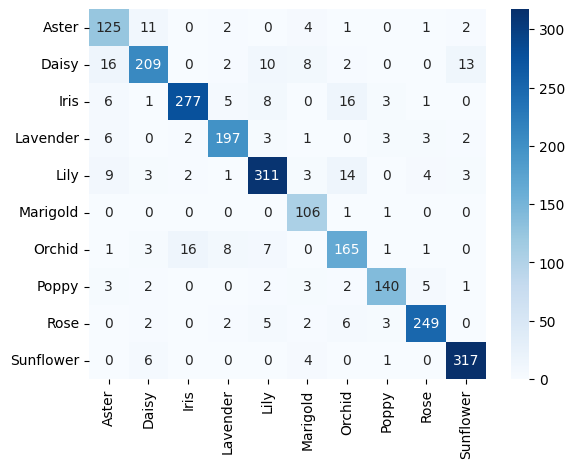

In [26]:
import seaborn as sns

class_names = train_dataset.classes

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)


In [27]:
model3.eval()
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(path):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    model3.eval()
    with torch.no_grad():
        outputs = model3(x)
        pred = outputs.argmax(dim=1).item()

    return pred

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

In [30]:
label_idx = predict_image("/kaggle/input/datasets/viennelee/test-photo/Beautiful-Flowers.png") 
print("Predicted class:", idx_to_class[label_idx])

Predicted class: Poppy


Goal: use sentence embedding to capture the meaning of the input text and output type of flower(s).

In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/input/flowers-meaning/2.csv", sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Name                   69 non-null     object
 1   Composition (Flowers)  68 non-null     object
 2   Occasion               68 non-null     object
 3   Emotion                68 non-null     object
 4   Colors                 68 non-null     object
 5   Description            68 non-null     object
dtypes: object(6)
memory usage: 3.4+ KB


In [6]:
df

,Name,Composition (Flowers),Occasion,Emotion,Colors,Description
0,101 Roses,White roses,Confession of love,Delight,"White, red, pink",Proposal for a beginning of a relationship
1,Summer Breeze,"Tulips, freesias",Birthday,Joy,"Yellow, orange, white",Bright and fresh flowers for warm days
2,Evening Star,"Orchid, lily",Wedding,Romance,"White, pink",For a ceremonial and magical moment
3,Warm Rain,"Sunflowers, hydrangea",Gratitude,Tenderness,"Yellow, white, blue",Lightness and warmth in every petal
4,Moonlight,"Callas, orchids, freesia",Anniversary,Calm,"White, lavender, pink",For special moments in life
...,...,...,...,...,...,...
64,Tropical Paradise,"Anthuriums, orchids, freesias",Vacation,Happiness,"Red, yellow",For those who love exotic vacations in warm co...
65,Tender Embrace,"Roses, lilies, chrysanthemums",Wedding Day,Love,"Pink, white",For the most important people in life
66,Sunrise,"Daffodils, tulips, gladioluses",First day of spring,Hope,"Yellow, orange",For new beginnings and new paths
67,Charming Harmony,"Peonies, roses, freesia",Confession of love,Admiration,"Red, pink, white",For people who captivate and amaze others


In [7]:
df.describe()

,Name,Composition (Flowers),Occasion,Emotion,Colors,Description
count,69,68,68,68,68,68
unique,68,64,28,22,43,68
top,Love Legend,"Roses, carnations, lilies",Confession of love,Joy,"Yellow, orange",Proposal for a beginning of a relationship
freq,2,2,7,9,8,1


In [8]:
df["full_description"] = (
    df["Name"] + ". " +
    df["Composition (Flowers)"] + ". " +
    df["Occasion"] + ". " +
    df["Emotion"] + ". " +
    df['Colors'] + '. ' +
    df["Description"]
)

df

,Name,Composition (Flowers),Occasion,Emotion,Colors,Description,full_description
0,101 Roses,White roses,Confession of love,Delight,"White, red, pink",Proposal for a beginning of a relationship,101 Roses. White roses. Confession of love. De...
1,Summer Breeze,"Tulips, freesias",Birthday,Joy,"Yellow, orange, white",Bright and fresh flowers for warm days,"Summer Breeze. Tulips, freesias. Birthday. Joy..."
2,Evening Star,"Orchid, lily",Wedding,Romance,"White, pink",For a ceremonial and magical moment,"Evening Star. Orchid, lily. Wedding. Romance. ..."
3,Warm Rain,"Sunflowers, hydrangea",Gratitude,Tenderness,"Yellow, white, blue",Lightness and warmth in every petal,"Warm Rain. Sunflowers, hydrangea. Gratitude. T..."
4,Moonlight,"Callas, orchids, freesia",Anniversary,Calm,"White, lavender, pink",For special moments in life,"Moonlight. Callas, orchids, freesia. Anniversa..."
...,...,...,...,...,...,...,...
64,Tropical Paradise,"Anthuriums, orchids, freesias",Vacation,Happiness,"Red, yellow",For those who love exotic vacations in warm co...,"Tropical Paradise. Anthuriums, orchids, freesi..."
65,Tender Embrace,"Roses, lilies, chrysanthemums",Wedding Day,Love,"Pink, white",For the most important people in life,"Tender Embrace. Roses, lilies, chrysanthemums...."
66,Sunrise,"Daffodils, tulips, gladioluses",First day of spring,Hope,"Yellow, orange",For new beginnings and new paths,"Sunrise. Daffodils, tulips, gladioluses. First..."
67,Charming Harmony,"Peonies, roses, freesia",Confession of love,Admiration,"Red, pink, white",For people who captivate and amaze others,"Charming Harmony. Peonies, roses, freesia. Con..."


In [9]:
df["full_description"] = df["full_description"].str.lower()
df.dropna()

,Name,Composition (Flowers),Occasion,Emotion,Colors,Description,full_description
0,101 Roses,White roses,Confession of love,Delight,"White, red, pink",Proposal for a beginning of a relationship,101 roses. white roses. confession of love. de...
1,Summer Breeze,"Tulips, freesias",Birthday,Joy,"Yellow, orange, white",Bright and fresh flowers for warm days,"summer breeze. tulips, freesias. birthday. joy..."
2,Evening Star,"Orchid, lily",Wedding,Romance,"White, pink",For a ceremonial and magical moment,"evening star. orchid, lily. wedding. romance. ..."
3,Warm Rain,"Sunflowers, hydrangea",Gratitude,Tenderness,"Yellow, white, blue",Lightness and warmth in every petal,"warm rain. sunflowers, hydrangea. gratitude. t..."
4,Moonlight,"Callas, orchids, freesia",Anniversary,Calm,"White, lavender, pink",For special moments in life,"moonlight. callas, orchids, freesia. anniversa..."
...,...,...,...,...,...,...,...
63,Winds of Change,"Lavender, freesias, callas",Success,Determination,"Purple, white",For those overcoming any obstacles,"winds of change. lavender, freesias, callas. s..."
64,Tropical Paradise,"Anthuriums, orchids, freesias",Vacation,Happiness,"Red, yellow",For those who love exotic vacations in warm co...,"tropical paradise. anthuriums, orchids, freesi..."
65,Tender Embrace,"Roses, lilies, chrysanthemums",Wedding Day,Love,"Pink, white",For the most important people in life,"tender embrace. roses, lilies, chrysanthemums...."
66,Sunrise,"Daffodils, tulips, gladioluses",First day of spring,Hope,"Yellow, orange",For new beginnings and new paths,"sunrise. daffodils, tulips, gladioluses. first..."


In [10]:
from sentence_transformers import SentenceTransformer
import torch

#paraphrase-multilingual-mpnet-base-v2 is a larger model with ~110M parameters. 
model_text = SentenceTransformer("all-MiniLM-L12-v2")

flower_classes = df["Composition (Flowers)"].tolist()
flower_colour = df["Colors"].tolist()
flower_descriptions = df["full_description"].tolist()

class_embs = model_text.encode(flower_descriptions, convert_to_tensor=True)

def predict_flower_from_text(query):
    query_emb = model_text.encode(query, convert_to_tensor=True) #pass the query to sentence embedding model and convert it to tensor
    scores = torch.nn.functional.cosine_similarity(query_emb, class_embs)

    top2_idx = torch.topk(scores, k=2).indices.tolist()

    best_idx = top2_idx[0]
    second_idx = top2_idx[1]
    #best_idx = torch.argmax(scores).item()
    print(f"first option: {flower_classes[best_idx]}, colour: {flower_colour[best_idx]}")#, model accuracy: {scores[best_idx].item()}")
    print(f"second option: {flower_classes[second_idx]}, colour: {flower_colour[second_idx]}")#, model accuracy: {scores[second_idx].item()}")

In [17]:
predict_flower_from_text("my wedding anniversary is coming. What flower should i buy for my wife? this is a new beginning. the season is summer")

first option: Daffodils, roses, lilies, colour: Yellow, pink
second option: Callas, orchids, freesia, colour: White, lavender, pink


In [16]:
predict_flower_from_text("its my aunt's funeral tomorrow. which flower should I get?")

first option: Roses, alstroemeria, freesia, colour: Pink, white
second option: Roses, carnations, lilies, colour: Pink, white, red


In [18]:
predict_flower_from_text("What flower means sorry, apologetic")

first option: Peony, chrysanthemum, roses, colour: Pink, white, red
second option: Orchids, lilies, freesias, colour: White, purple


The model accuracy hover around 0.4-0.6. This is because the sentence has fuzzy concept of what it means. 

In [1]:
torch.save(model3.state_dict(), "cnn_flower_classifier.pth")


NameError: name 'torch' is not defined

In [11]:
torch.save(class_embs, "class_embs.pt")

In [46]:
flower_classes = ["Aster", "Daisy", "Iris", "Lavender", "Lily", 
                  "Marigold", "Orchid", "Poppy", "Rose", "Sunflower"]

import json
with open("/kaggle/working/flower_labels.json", "w") as f: 
    json.dump(flower_classes, f)

In [49]:
os.listdir("/kaggle/working")


['.virtual_documents',
 'model.zip',
 'flower_labels.json',
 'cnn_flower_classifier.pth',
 'class_embs.pt']

In [51]:
!zip -r cnn_flower_classifier.zip /kaggle/working/cnn_flower_classifier.pth

  adding: kaggle/working/cnn_flower_classifier.pth

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 8%)


In [17]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Rebuild the architecture EXACTLY as during training
cnn_model = models.efficientnet_b0(weights=None)

cnn_model.classifier = nn.Sequential(
    nn.Linear(1280, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 10)
)

# 2. Load the saved weights (state_dict)
state_dict = torch.load(
    "/kaggle/input/datasets/viennelee/fin-cnn-flowers/cnn_flower_classifier.pth",
    map_location="cpu"
)
cnn_model.load_state_dict(state_dict)

# 3. Set to eval mode
cnn_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [24]:
from PIL import Image

image = Image.open("/kaggle/input/flowers/Testing Data/Testing Data/Daisy/Daisy-Test (1).jpeg").convert("RGB")

def detect_flowers(image):
    # Convert PIL → numpy
    img_np = np.array(image)

    # YOLO detection
    results = model(img_np)[0]

    annotated = img_np.copy()
    predictions = []

    for box in results.boxes:
        # YOLO bounding box
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        # Crop region for CNN
        crop = image.crop((x1, y1, x2, y2))

        # CNN classification
        crop_tensor = transform(crop).unsqueeze(0)
        with torch.no_grad():
            logits = cnn_model(crop_tensor)
            probs = torch.softmax(logits, dim=1)
            conf_cnn, cls_idx = torch.max(probs, dim=1)

        flower_name = flower_labels[cls_idx.item()]
        conf_cnn = conf_cnn.item() * 100

        # Draw bounding box + label
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(
            annotated,
            f"{flower_name} {conf_cnn:.1f}%",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

        # Save prediction
        predictions.append({
            "flower": flower_name,
            "confidence": round(conf_cnn, 2),
            "box": [x1, y1, x2, y2]
        })

    # Convert back to PIL
    annotated_pil = Image.fromarray(annotated)

    return annotated_pil, predictions

In [25]:
annotated_image, predictions = detect_flowers(image)


0: 480x640 (no detections), 11.1ms
Speed: 2.4ms preprocess, 11.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
